In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from data import *
from metrics import *

/mnt/nvme0/home/utbt/KhoaVM/khoa-env/lib/python3.12/site-packages/albumentations/core/validation.py:132: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [2]:
x, y = get_stanford_background()

In [3]:
x = cv2.imread(x[0])
y = cv2.imread(y[0], cv2.IMREAD_GRAYSCALE)

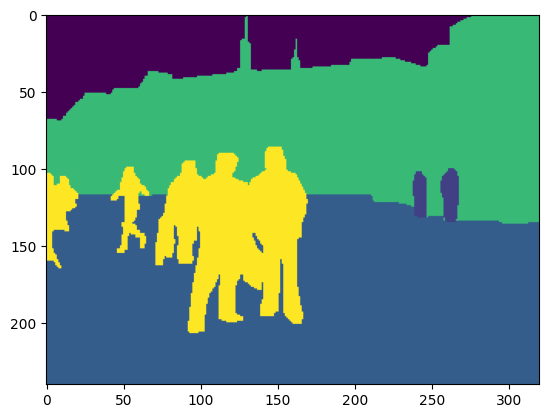

In [4]:
plt.imshow(y)

In [5]:
from mobile_sam import sam_model_registry, SamPredictor

sam_checkpoint = "/mnt/nvme0/home/utbt/KhoaVM/NoisySAM/checkpoints/mobile_sam.pt"
model_type = "vit_t"

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
sam.eval()

predictor = SamPredictor(sam)

/mnt/nvme0/home/utbt/KhoaVM/khoa-env/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/mnt/nvme0/home/utbt/KhoaVM/khoa-env/lib/python3.12/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/mnt/nvme0/home/utbt/KhoaVM/NoisySAM/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/mnt/nvme0/home/utbt/KhoaVM/NoisySAM/mobile_sam/modeling/tiny_vit_sam

In [6]:
predictor.set_image(x)

In [7]:
def split_masks(y):
    masks = []

    ids = np.unique(y)

    for gid in ids:
        masks.append(y == gid)

    return masks

def sample_points(mask, n_points=5):
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return None

    points = []

    cx = int(xs.mean())
    cy = int(ys.mean())
    points.append([cx, cy])

    if len(xs) > n_points:
        idx = np.random.choice(len(xs), n_points-1, replace=False)
        for i in idx:
            points.append([xs[i], ys[i]])

    return np.array(points)

def sam_predict_mask(predictor, image, points):

    labels = np.ones(len(points))

    masks, scores, _ = predictor.predict(
        point_coords=points,
        point_labels=labels,
        multimask_output=False
    )

    return masks[0]

def evaluate_sam(image, gt_mask, predictor):

    masks = split_masks(gt_mask)

    ious = []
    dices = []
    precisions = []
    recalls = []

    preds = []

    predictor.set_image(image)

    for mask in masks:

        points = sample_points(mask, n_points=5)

        if points is None:
            continue

        pred = sam_predict_mask(predictor, image, points)
        preds.append(pred)

        metrics = compute_metrics(pred, mask)

        ious.append(metrics["iou"])
        dices.append(metrics["dice"])
        precisions.append(metrics["precision"])
        recalls.append(metrics["recall"])

    if len(ious) == 0:
        return None

    mean_metrics = {
        "miou": np.mean(ious),
        "mdice": np.mean(dices),
        "mprecision": np.mean(precisions),
        "mrecall": np.mean(recalls)
    }

    return mean_metrics, preds, masks


In [8]:
metrics, preds, masks = evaluate_sam(x, y, predictor)

In [9]:
metrics

{'miou': np.float64(0.819748102805713),
 'mdice': np.float64(0.8903415736557134),
 'mprecision': np.float64(0.8934648168698983),
 'mrecall': np.float64(0.9159429288533127)}

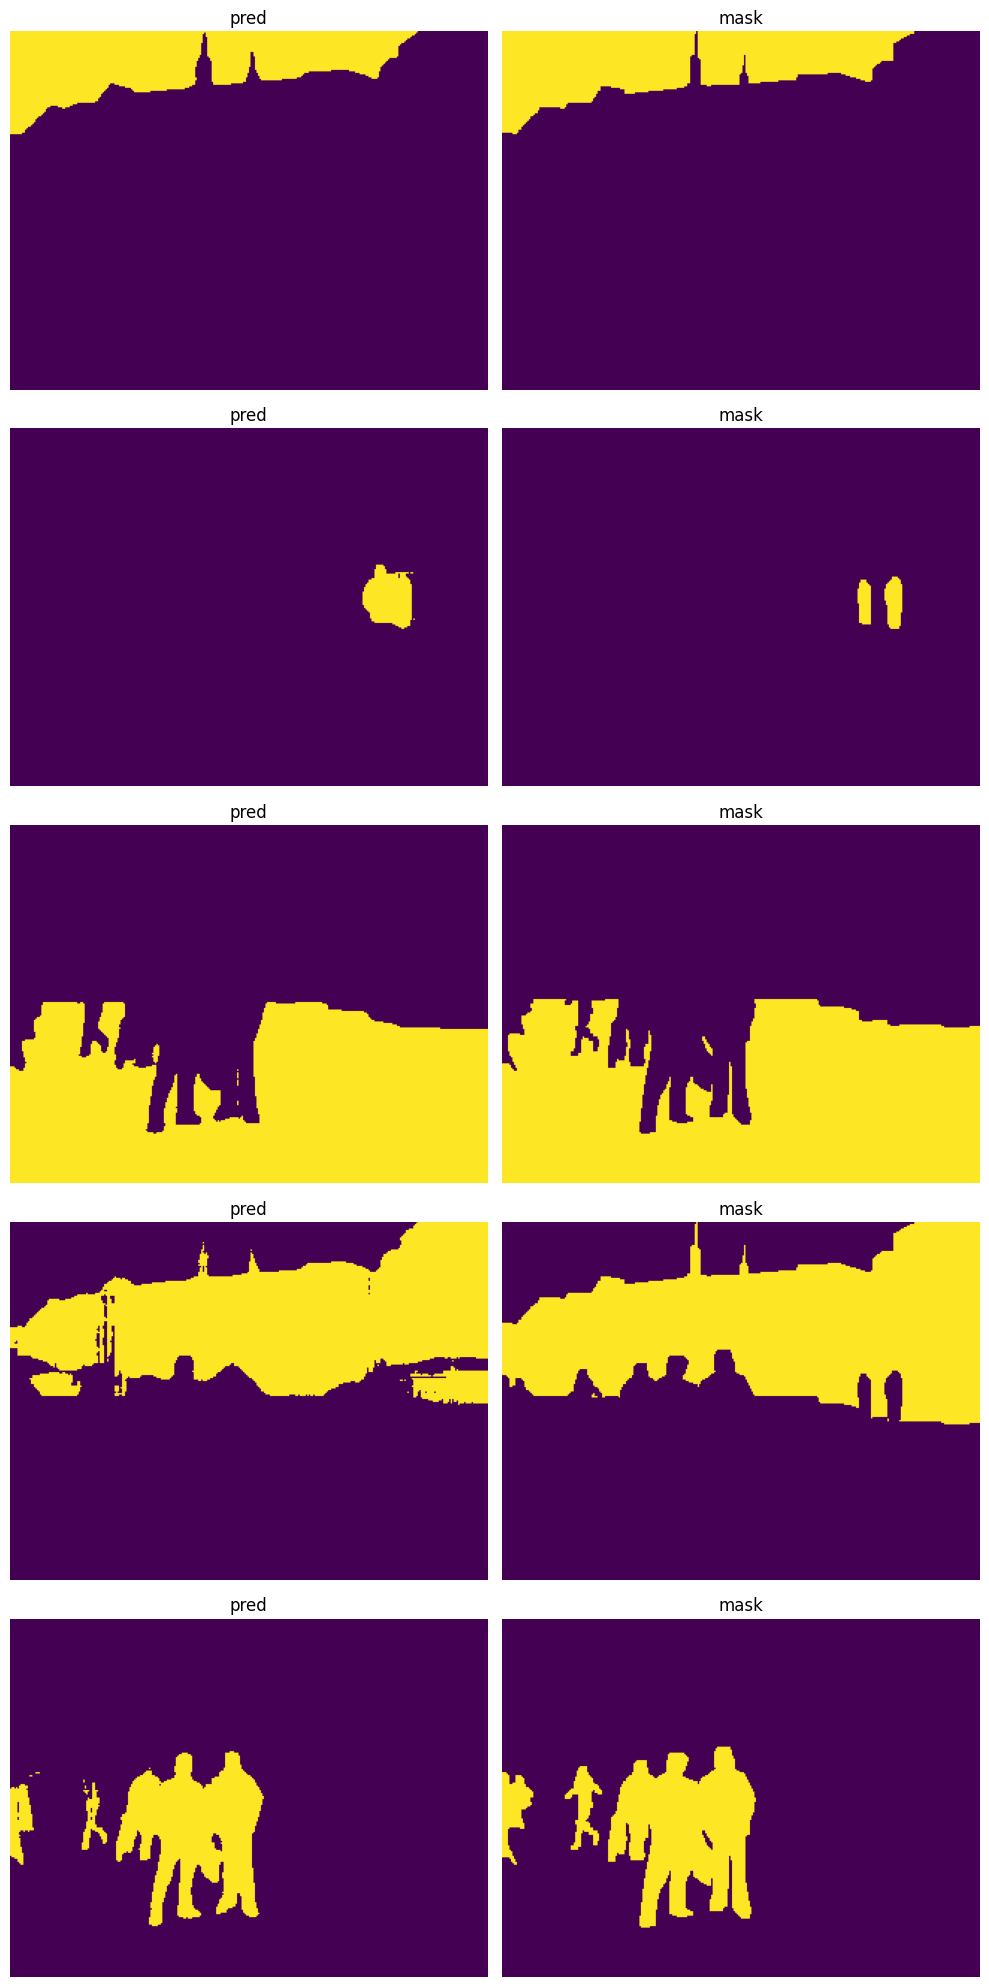

In [23]:
n = len(masks)

plt.figure(figsize=(10, 4 * n))

for i in range(n):
    plt.subplot(n, 2, 2*i + 1)
    plt.imshow(preds[i])
    plt.axis("off")
    plt.title("pred")

    plt.subplot(n, 2, 2*i + 2)
    plt.imshow(masks[i])
    plt.axis("off")
    plt.title("mask")

plt.tight_layout()
plt.show()